# Fast Fourier Transform

examples

In [19]:
import numpy as np
from fractions import Fraction
from functools import reduce, lru_cache, partial

from scipy import linalg as la
import scipy.optimize as opt
from scipy import special, interpolate, integrate
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)

def sign(x):
    s = np.sign(x)
    return s if s else 1

In [20]:
def generate_f(n):
    w = np.exp(complex(0, - 2 * np.pi / n))
    return np.vander(w ** np.arange(n), increasing=True)


def generate_f_inv(n):
    w = np.exp(complex(0, - 2 * np.pi / n))
    return np.vander(w ** (-np.arange(n)), increasing=True) / n


n = 4
F = generate_f(n)
F_inv = generate_f_inv(n)
F @ F_inv

array([[ 1.+0.j, -0.+0.j,  0.+0.j,  0.+0.j],
       [-0.-0.j,  1.+0.j, -0.+0.j,  0.+0.j],
       [ 0.-0.j, -0.-0.j,  1.+0.j, -0.+0.j],
       [ 0.-0.j,  0.-0.j, -0.-0.j,  1.+0.j]])

In [21]:
# 12.1
x = np.array([4, 0, 3, 6, 2, 9, 6, 5])
print(x.sum())
generate_f(8) @ x

35


array([35.      +0.j      , -5.071068+8.656854j, -3.      +2.j      ,
        9.071068+2.656854j, -5.      +0.j      ,  9.071068-2.656854j,
       -3.      -2.j      , -5.071068-8.656854j])

In [22]:
x = np.ones(8)
x[1::2] *= -1
print(x.sum())
generate_f(8) @ x

0.0


array([ 0.+0.j, -0.+0.j, -0.-0.j, -0.-0.j,  8.+0.j, -0.+0.j, -0.+0.j,
       -0.+0.j])

computer problems

[0.+0.j 0.+0.j 0.+0.j 0.+0.j 8.+0.j 0.+0.j 0.+0.j 0.+0.j]
[ 0.+0.j -0.+0.j -0.-0.j -0.-0.j  8.+0.j -0.+0.j -0.+0.j -0.+0.j]

[8.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
[ 8.+0.j -0.+0.j -0.+0.j -0.+0.j -0.+0.j -0.-0.j -0.-0.j -0.-0.j]

[0.+0.j 0.+0.j 0.+0.j 0.+0.j 8.+0.j 0.+0.j 0.+0.j 0.+0.j]
[ 0.+0.j -0.+0.j -0.-0.j -0.-0.j  8.+0.j -0.+0.j -0.+0.j -0.+0.j]

[8.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
[ 8.+0.j -0.+0.j -0.+0.j -0.+0.j -0.+0.j -0.-0.j -0.-0.j -0.-0.j]



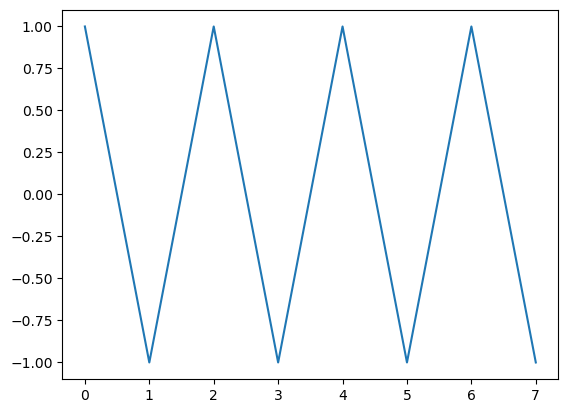

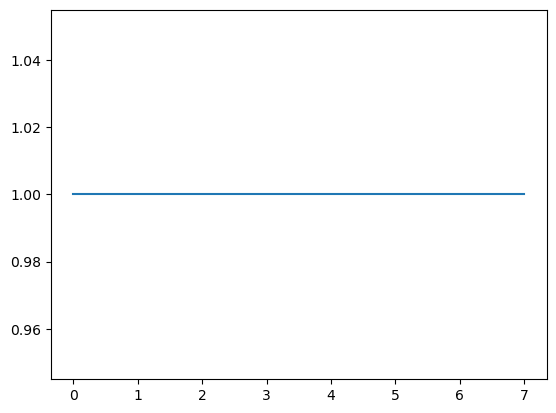

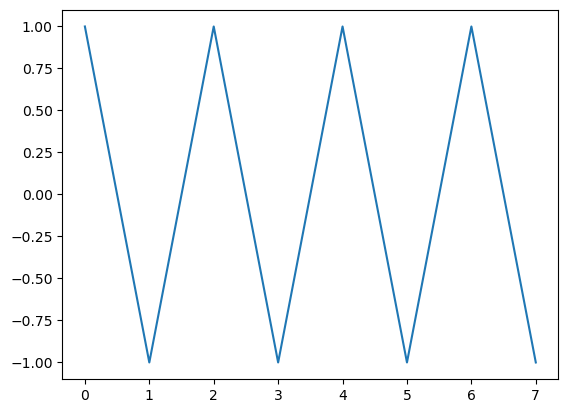

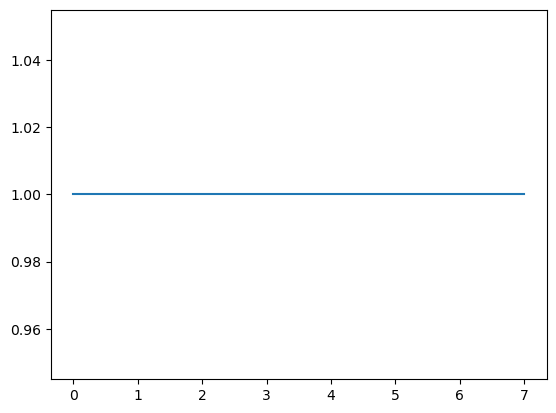

In [24]:
# 12.1
for m in range(1, 5):
    s = np.cos(m * np.pi * np.arange(8))
    plt.figure()
    plt.plot(s)
    print(np.fft.fft(s))
    print(generate_f(8) @ s)
    print()

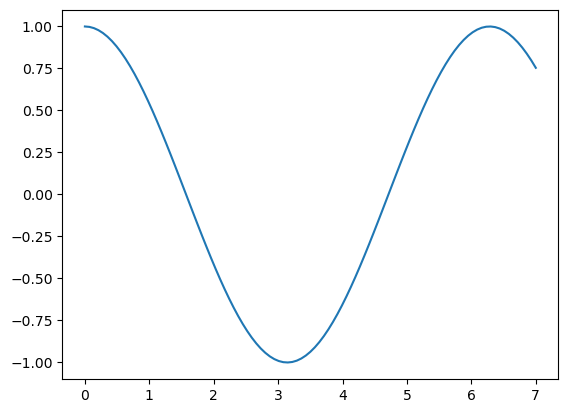

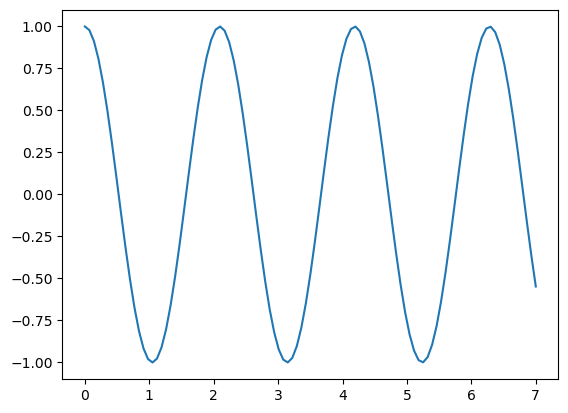

In [25]:
for m in 1, 3:
    plt.figure()
    x = np.linspace(0, 7, 101)
    plt.plot(x, np.cos(m * x))

[ 1.478254+0.j        3.068235+2.427965j -0.197667-1.060055j
  0.239052-0.324669j  0.302506+0.j        0.239052+0.324669j
 -0.197667+1.060055j  3.068235-2.427965j]
[ 1.478254+0.j        3.068235+2.427965j -0.197667-1.060055j
  0.239052-0.324669j  0.302506+0.j        0.239052+0.324669j
 -0.197667+1.060055j  3.068235-2.427965j]

[0.255801+0.j       0.250259+0.11996j  0.223367+0.290821j
 0.062033+0.719667j 6.672881+0.j       0.062033-0.719667j
 0.223367-0.290821j 0.250259-0.11996j ]
[0.255801+0.j       0.250259+0.11996j  0.223367+0.290821j
 0.062033+0.719667j 6.672881+0.j       0.062033-0.719667j
 0.223367-0.290821j 0.250259-0.11996j ]



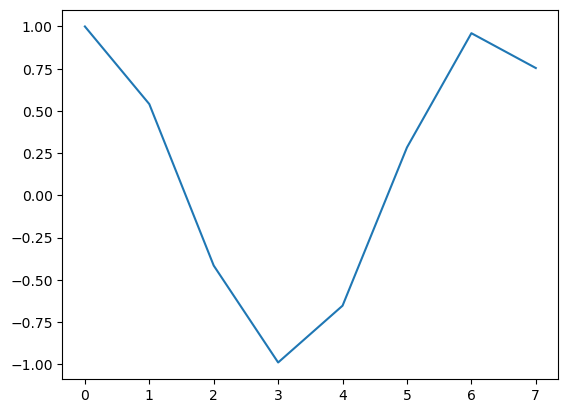

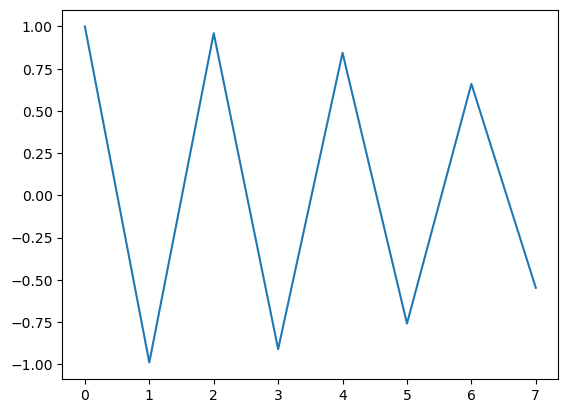

In [26]:
for m in 1, 3:
    s = np.cos(m * np.arange(8))
    plt.figure()
    plt.plot(s)
    print(np.fft.fft(s))
    print(generate_f(8) @ s)
    print()

In [ ]:
# 12.2
# (a)
ts = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]
xs = [408, 89, -66, 10, 338, 807, 1238, 1511, 1583, 1462, 1183, 804]

A = np.zeros((12, 12))
for i in range(12):
    A[i, :7] = np.cos(2 * np.pi / 360 * np.arange(7) * ts[i])
    A[i, 7:] = np.sin(2 * np.pi / 360 * np.arange(1, 6) * ts[i])

ps = la.solve(A, xs)
print(ps)

[ 780.583333 -411.014367   43.416667   -4.333333   -1.083333    0.3477
    0.083333 -720.227893   -2.165064    5.5        -1.010363   -0.272107]


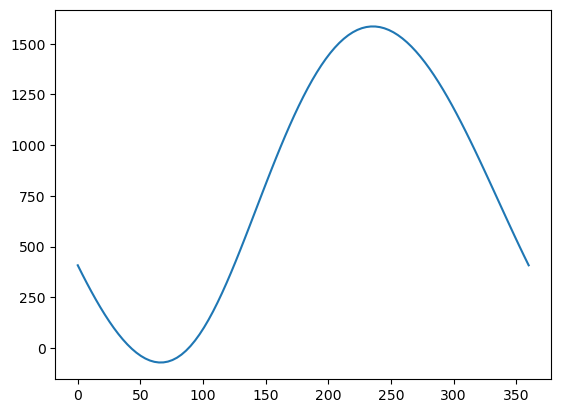

In [36]:
def f(x):
    return (np.cos(2 * np.pi / 360 * np.arange(7) * x) @  ps[:7]) + (np.sin(2 * np.pi / 360 * np.arange(1, 6) * x) @ ps[7:])


plt.plot(np.linspace(0, 360, 101), [f(x) for x in np.linspace(0, 360, 101)])

In [42]:
ys = np.fft.fft(xs)
ys / 12

array([ 780.583333  +0.j      , -205.507183+360.113946j,
         21.708333  +1.082532j,   -2.166667  -2.75j    ,
         -0.541667  +0.505181j,    0.17385   +0.136054j,
          0.083333  -0.j      ,    0.17385   -0.136054j,
         -0.541667  -0.505181j,   -2.166667  +2.75j    ,
         21.708333  -1.082532j, -205.507183-360.113946j])

In [40]:
ps

array([ 780.583333, -411.014367,   43.416667,   -4.333333,   -1.083333,
          0.3477  ,    0.083333, -720.227893,   -2.165064,    5.5     ,
         -1.010363,   -0.272107])

In [44]:
# 12.3
n = 8
xs = np.random.random(8)
ys = np.fft.fft(xs)
print(xs)
print(ys)

[0.942202 0.815279 0.901248 0.187309 0.026544 0.225318 0.584763 0.452805]
[ 4.135467+0.j        1.520557-0.545916j -0.517265-0.400484j
  0.310758+0.087053j  0.774047+0.j        0.310758-0.087053j
 -0.517265+0.400484j  1.520557+0.545916j]


In [56]:
xs_1 = np.roll(xs, shift=1)
ys_1 = np.fft.fft(xs_1)
print(xs_1)
print(ys_1)

[0.452805 0.942202 0.815279 0.901248 0.187309 0.026544 0.225318 0.584763]
[ 4.135467+0.j        0.689175-1.461217j -0.400484+0.517265j
 -0.158183-0.281295j -0.774047+0.j       -0.158183+0.281295j
 -0.400484-0.517265j  0.689175+1.461217j]


In [54]:
xs_2 = np.roll(xs, shift=2)
ys_2 = np.fft.fft(xs_2)
print(xs_2)
print(ys_2)

[0.584763 0.452805 0.942202 0.815279 0.901248 0.187309 0.026544 0.225318]
[ 4.135467+0.j       -0.545916-1.520557j  0.517265+0.400484j
 -0.087053+0.310758j  0.774047+0.j       -0.087053-0.310758j
  0.517265-0.400484j -0.545916+1.520557j]


In [57]:
print(np.abs(ys))
print(np.abs(ys_1))
print(np.abs(ys_2))

[4.135467 1.615586 0.654179 0.322721 0.774047 0.322721 0.654179 1.615586]
[4.135467 1.615586 0.654179 0.322721 0.774047 0.322721 0.654179 1.615586]
[4.135467 1.615586 0.654179 0.322721 0.774047 0.322721 0.654179 1.615586]


In [70]:
np.allclose(ys * np.exp([complex(0, -2 * np.pi * i / n) for i in range(n)]), ys_1)

True

In [73]:
# 12.4
xs = np.ones(5)
xs_head = np.concatenate([xs, np.zeros(3)])
ys = np.fft.fft(xs)
ys_head = np.fft.fft(xs_head)
print(ys)
print(ys_head)

[5.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
[5.+0.j       0.-2.414214j 1.+0.j       0.-0.414214j 1.+0.j
 0.+0.414214j 1.+0.j       0.+2.414214j]


In [75]:
generate_f(5) @ xs

array([ 5.+0.j, -0.+0.j,  0.-0.j,  0.-0.j,  0.+0.j])

In [76]:
generate_f(8) @ xs_head

array([ 5.+0.j      , -0.-2.414214j,  1.+0.j      , -0.-0.414214j,
        1.+0.j      , -0.+0.414214j,  1.-0.j      , -0.+2.414214j])

In [ ]:
# 12.7
from collections import Counter
for n in range(1, 17):
    cnt = Counter(la.eigvals(generate_f(n) / np.sqrt(n)).round(1))
    print(n, cnt)


for n in 101,:
    cnt = Counter(la.eigvals(generate_f(n) / np.sqrt(n)).round(1))
    print(n, cnt)


# 1: n // 4 + 1
# -1: (n - 2) // 4 + 1
# -j: (n - 3) // 4 + 1
# j: (n -5) // 4 + 1

1 Counter({np.complex128(1+0j): 1})
2 Counter({np.complex128(1-0j): 1, np.complex128(-1-0j): 1})
3 Counter({np.complex128(1-0j): 1, np.complex128(-1-0j): 1, np.complex128(-1j): 1})
4 Counter({np.complex128(1-0j): 2, np.complex128(-1-0j): 1, np.complex128(-1j): 1})
5 Counter({np.complex128(1-0j): 2, np.complex128(-1-0j): 1, np.complex128(-0+1j): 1, np.complex128(-1j): 1})
6 Counter({np.complex128(1-0j): 2, np.complex128(-1-0j): 2, np.complex128(-1j): 1, np.complex128(-0+1j): 1})
7 Counter({np.complex128(1-0j): 2, np.complex128(-1-0j): 2, np.complex128(-1j): 2, np.complex128(-0+1j): 1})
8 Counter({np.complex128(1+0j): 3, np.complex128(-1-0j): 2, np.complex128(-1j): 2, np.complex128(1j): 1})
9 Counter({np.complex128(1+0j): 3, np.complex128(-1j): 2, np.complex128(-0+1j): 2, np.complex128(-1+0j): 2})
10 Counter({np.complex128(1-0j): 3, np.complex128(-1-0j): 3, np.complex128(-1j): 2, np.complex128(-0+1j): 2})
11 Counter({np.complex128(1-0j): 3, np.complex128(-1-0j): 3, np.complex128(-1j): 3,

In [88]:
# 12.8
n = 8
C = la.circulant(np.random.random(n))
1 / n * (generate_f(n) @ C @ generate_f(n).conj().T)

array([[ 5.306634+0.j      , -0.      -0.j      , -0.      -0.j      ,
        -0.      -0.j      , -0.      +0.j      , -0.      +0.j      ,
        -0.      +0.j      , -0.      +0.j      ],
       [-0.      +0.j      ,  1.302163+0.170445j, -0.      -0.j      ,
        -0.      -0.j      , -0.      -0.j      , -0.      +0.j      ,
        -0.      +0.j      , -0.      +0.j      ],
       [-0.      +0.j      , -0.      +0.j      , -0.528234-0.476962j,
         0.      +0.j      , -0.      +0.j      ,  0.      +0.j      ,
         0.      +0.j      ,  0.      +0.j      ],
       [-0.      +0.j      , -0.      +0.j      ,  0.      -0.j      ,
        -0.016154+0.581583j,  0.      -0.j      ,  0.      -0.j      ,
         0.      -0.j      , -0.      -0.j      ],
       [-0.      +0.j      , -0.      +0.j      ,  0.      +0.j      ,
        -0.      -0.j      ,  0.309107+0.j      , -0.      -0.j      ,
         0.      -0.j      , -0.      -0.j      ],
       [-0.      -0.j      , -0.   

In [98]:
# 12.9
def fft(x, y, n, w):
    if n == 1:
        y[0] = x[0]
    else:
        q, t = np.zeros(n//2).astype(complex), np.zeros(n//2).astype(complex)
        fft(x[::2], q, n//2, w**2)
        fft(x[1::2], t, n//2, w**2)
        for k in range(n):
            y[k] = q[k % (n//2)] + w ** k * t[k % (n//2)]


n = 8
w = np.exp(complex(0, -2 * np.pi / n))
y = np.random.random(n).astype(complex)
x = np.random.random(n)
fft(x, y, n, w)
print(y)
print(np.fft.fft(x))
print(generate_f(n) @ x)

[ 2.41509 +0.j        0.255152-0.953465j -0.050911-0.437754j
 -0.424897+0.64125j   0.801785+0.j       -0.424897-0.64125j
 -0.050911+0.437754j  0.255152+0.953465j]
[ 2.41509 +0.j        0.255152-0.953465j -0.050911-0.437754j
 -0.424897+0.64125j   0.801785+0.j       -0.424897-0.64125j
 -0.050911+0.437754j  0.255152+0.953465j]
[ 2.41509 +0.j        0.255152-0.953465j -0.050911-0.437754j
 -0.424897+0.64125j   0.801785+0.j       -0.424897-0.64125j
 -0.050911+0.437754j  0.255152+0.953465j]


In [109]:
# 12.12
a = [1, 2, 3]
b = [0, 1, 0.5]

np.convolve(a, b)

array([0. , 1. , 2.5, 4. , 1.5])

In [108]:
np.fft.ifft(np.fft.fft(a, 5) * np.fft.fft(b, 5))

array([-0. +0.j,  1. +0.j,  2.5+0.j,  4. +0.j,  1.5+0.j])

In [118]:
# 12.23
np.random.seed(0)
p3 = Polynomial(np.random.random(3))
p5 = Polynomial(np.random.random(5))

print((p3 * p5).coef)

def multi_poly(p1, p2):
    v1 = np.fft.fft(p1.coef, len(p1.coef) + len(p2.coef) - 1)
    v2 = np.fft.fft(p2.coef, len(p1.coef) + len(p2.coef) - 1)
    return np.fft.ifft(v1 * v2)

print(multi_poly(p3, p5))

[0.299039 0.622202 0.985904 0.957454 1.191696 0.901548 0.537528]
[0.299039+0.j 0.622202+0.j 0.985904+0.j 0.957454+0.j 1.191696+0.j
 0.901548+0.j 0.537528+0.j]


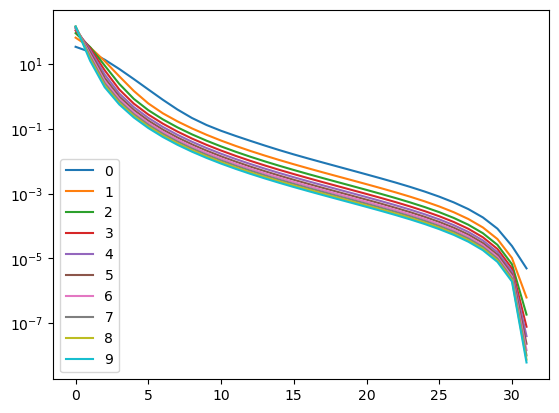

In [139]:
# 12.14
# (a)
n = 64
A = 2 * np.eye(n) - np.diag(np.ones(n-1), 1) - np.diag(np.ones(n-1), -1)
b = np.zeros(n)

def gauss_seidel(A, b, x0, tol=1e-8, n=1000, step=1):
    x = np.array(x0)
    history, m, A = [x.tolist()], len(b), np.array(A)
    for _ in range(n):
        r = 0
        for i in range(0, m, step):
            v = b[i] - (x[np.arange(m) != i] @ A[i, np.arange(m) != i])
            v /= A[i, i]
            r += (x[i] - v) ** 2
            x[i] = v

        history.append(x.tolist())
        if np.sqrt(r) < tol:
            break
    return np.array(history)


x = np.ones(n)
for i in range(10):
    x = gauss_seidel(A, b, x, n=10)[-1]
    y = np.fft.fft(x)
    p = y * y.conj()
    plt.semilogy(p.real[1:n//2+1], label=i)
plt.legend()

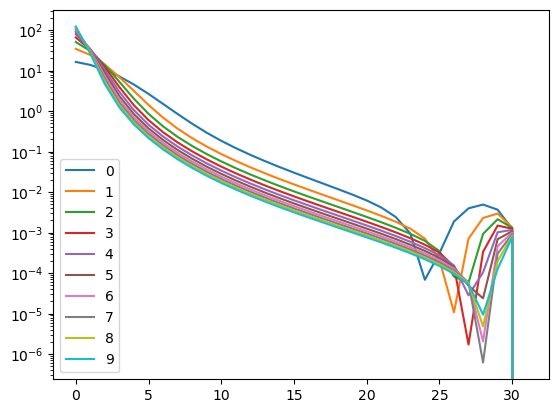

In [140]:
# (b)
def jacobi(A, b, x0, tol=1e-3, n=1000):
    xold = np.array(x0)
    xnew = np.zeros_like(x0)
    history, m, A = [xold.tolist()], len(b), np.array(A)
    for _ in range(n):
        for i in range(m):
            xnew[i] = b[i] - (xold[np.arange(m) != i] @ A[i, np.arange(m) != i])
            xnew[i] /= A[i, i]
        history.append(xnew.tolist())
        if la.norm(xnew - xold) < tol:
            print(xold, xnew, xnew - xold, la.norm(xnew - xold), tol)
            break
        xold[:] = xnew[:]
    return np.array(history)


x = np.ones(n)
for i in range(10):
    x = jacobi(A, b, x, n=10)[-1]
    y = np.fft.fft(x)
    p = y * y.conj()
    plt.semilogy(p.real[1:n//2+1], label=i)
plt.legend()

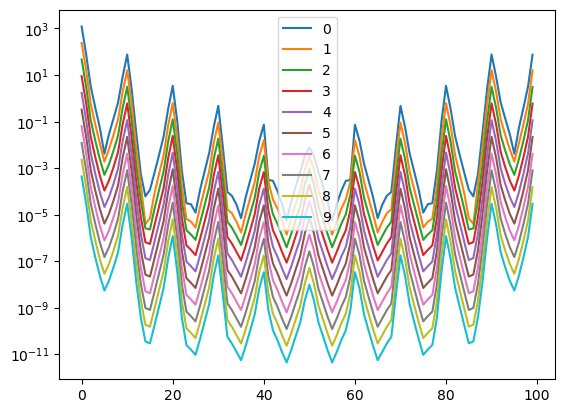

In [149]:
def laplace(n, skip=lambda i, j: False):
    A = 4 * np.eye(n ** 2)
    for k in range(n ** 2):
        i, j = divmod(k, n)

        if not skip(i, j):
            if i - 1 >= 0:
                A[k, (i-1)*n + j] = -1
            if i + 1 < n:
                A[k, (i+1)*n + j] = -1
            if j - 1 >= 0:
                A[k, k - 1] = -1
            if j + 1 < n:
                A[k, k + 1] = -1
    return A


n = 10
A = laplace(n)
b = np.zeros(n**2)

x = np.ones(n**2)
for i in range(10):
    x = gauss_seidel(A, b, x, n=10)[-1]
    y = np.fft.fft(x)
    p = y * y.conj()
    plt.semilogy(p.real, label=i)
plt.legend()

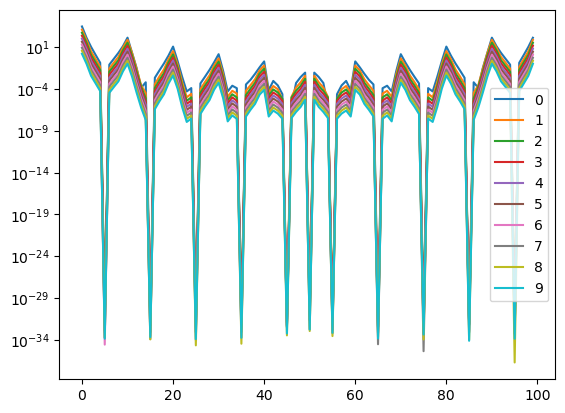

In [152]:
x = np.ones(n**2)
for i in range(10):
    x = jacobi(A, b, x, n=10)[-1]
    y = np.fft.fft(x)
    p = y * y.conj()
    plt.semilogy(p.real, label=i)
plt.legend()